In [2]:
import pandas as pd
import zipfile
import io
import numpy as np
from datetime import datetime

caminho_zip_principal = r'data/raw/dataset2018.zip'
nomes_mun = pd.read_csv('municipio_tse_ibge.csv', sep=';', encoding='latin1')

dados = []
arquivos_processados = 0
total_contingencias = 0


with zipfile.ZipFile(caminho_zip_principal, 'r') as zip_mestre:
    arquivos = zip_mestre.namelist()
    total_urnas = sum(1 for a in arquivos if a.endswith('.logjez'))
    
    for caminho_interno in arquivos:
        if caminho_interno.endswith('.logjez'):
            
            
            partes = caminho_interno.split('/')
            cod_mun = partes[1]
            zona = partes[2]
            secao = partes[3]
            
            inicio_voto = None
            urna_contingencia = "Não"
            timeout_biometria = 0
            tecla_indevida = 0
            inatividade = 0
            sem_biometria = 0
            titulo_invalido = 0
            
            
            tdvpe_por_turno = {
                "1º Turno": {"antes_17": [], "depois_17": []}, 
                "2º Turno": {"antes_17": [], "depois_17": []}
            }
            huv_por_turno = {"1º Turno": None, "2º Turno": None}
            turno_atual = "1º Turno"
            
            
            with zip_mestre.open(caminho_interno) as sub_zip_bytes:
                with zipfile.ZipFile(io.BytesIO(sub_zip_bytes.read())) as logjez:
                    with logjez.open('logd.dat') as f:
                        arquivo_log = io.TextIOWrapper(f, encoding='latin1')
                        
                        for linha in arquivo_log:
                            texto_busca = linha.lower()
                            if secao in ('0', '00', '000', '0000'):
                                   if "seção eleitoral" in texto_busca:
                                      secao_nova = texto_busca.split("seção eleitoral")[1].replace(":", "").split()[0]
                                      if secao_nova not in ('0', '00', '000', '0000'):
                                         secao = secao_nova
                            if "urna de contingência" in texto_busca:
                                urna_contingencia = "Sim"
                            if "iniciando aplicação" in texto_busca and "turno" in texto_busca:
                                if "1º turno" in texto_busca:
                                    turno_atual = "1º Turno"
                                elif "2º turno" in texto_busca:
                                    turno_atual = "2º Turno"
                            
                            
                            elif "eleitor foi habilitado" in texto_busca:
                                tempo_texto = linha[0:19]
                                inicio_voto = datetime.strptime(tempo_texto, "%d/%m/%Y %H:%M:%S")
                            
                            
                            elif "o voto do eleitor foi computado" in texto_busca:
                                if inicio_voto is not None:
                                    tempo_texto = linha[0:19]
                                    fim_voto = datetime.strptime(tempo_texto, "%d/%m/%Y %H:%M:%S")
                                    voto = (fim_voto - inicio_voto).total_seconds()
                                    
                                    if fim_voto.hour < 17:
                                        tdvpe_por_turno[turno_atual]["antes_17"].append(voto)
                                    else:
                                        tdvpe_por_turno[turno_atual]["depois_17"].append(voto)
                                        
                                    huv_por_turno[turno_atual] = fim_voto.strftime("%H:%M:%S")
                                    inicio_voto = None
                            if "timeout de reconhecimento do dedo" in texto_busca and turno_atual == "1º Turno":
                              timeout_biometria += 1
                            if "o eleitor não possui biometria" in texto_busca and turno_atual == "1º Turno":
                             sem_biometria += 1
                            if "tecla indevida pressionada" in texto_busca and turno_atual == "1º Turno":
                             tecla_indevida += 1
                            if "eleitor sem atividade por" in texto_busca and turno_atual == "1º Turno":
                             inatividade += 1
                            if "título inválido" in texto_busca and turno_atual == "1º Turno":
                                titulo_invalido += 1
        
            for turno, cestas in tdvpe_por_turno.items():
                votos_antes = cestas["antes_17"]
                votos_depois = cestas["depois_17"]
                
                if len(votos_antes) > 0 or len(votos_depois) > 0:
                    
                    delta_antes = round(np.mean(votos_antes), 2) if len(votos_antes) > 0 else 0.0
                    desvio_antes = round(np.std(votos_antes), 2) if len(votos_antes) > 1 else 0.0
                    
                    delta_depois = round(np.mean(votos_depois), 2) if len(votos_depois) > 0 else 0.0
                    desvio_depois = round(np.std(votos_depois), 2) if len(votos_depois) > 1 else 0.0              
                    if urna_contingencia == "Sim":
                        total_contingencias += 1
                    
                    dados.append({
                        'NM_MUNICIPIO': cod_mun,
                        'NR_ZONA': zona,
                        'NR_SECAO': secao,
                        'TURNO': turno, 
                        'CONTINGENCIA': urna_contingencia, 
                        'QT_ELEITORES_ANTES_17': len(votos_antes),
                        'DELTA_T_ANTES_17': delta_antes,
                        'DESVIO_ANTES_17': desvio_antes,
                        'QT_ELEITORES_DEPOIS_17': len(votos_depois),
                        'DELTA_T_DEPOIS_17': delta_depois,
                        'DESVIO_DEPOIS_17': desvio_depois,
                        'ULTIMO_VOTO': huv_por_turno[turno],
                        'TIMEOUT_BIOMETRIA': timeout_biometria,
                        'TECLA_INDEVIDA': tecla_indevida,
                        'INATIVIDADE': inatividade,
                        'SEM_BIOMETRIA': sem_biometria,
                        'TITULO_INVALIDO': titulo_invalido,
                    })
                    
            arquivos_processados += 1
          

df_csv = pd.DataFrame(dados)
nome_arquivo_csv = 'df_csv_2018.csv'

municipios_se = nomes_mun[nomes_mun['SG_UF'] == 'SE'].copy()
municipios_se['CD_MUNICIPIO_TSE'] = municipios_se['CD_MUNICIPIO_TSE'].astype(str)
df_csv['NM_MUNICIPIO'] = df_csv['NM_MUNICIPIO'].astype(str)

df_csv = df_csv.merge(
    municipios_se[['CD_MUNICIPIO_TSE', 'NM_MUNICIPIO_TSE']], 
    left_on='NM_MUNICIPIO', 
    right_on='CD_MUNICIPIO_TSE', 
    how='left'
)
                      
df_csv = df_csv.drop(columns=['NM_MUNICIPIO', 'CD_MUNICIPIO_TSE'], errors='ignore')
df_csv = df_csv.rename(columns={'NM_MUNICIPIO_TSE': 'NM_MUNICIPIO'})

colunas = ['NM_MUNICIPIO', 'NR_ZONA', 'NR_SECAO', 'TURNO', 'CONTINGENCIA',
    'QT_ELEITORES_ANTES_17', 'DELTA_T_ANTES_17', 'DESVIO_ANTES_17',
    'QT_ELEITORES_DEPOIS_17', 'DELTA_T_DEPOIS_17', 'DESVIO_DEPOIS_17', 
    'ULTIMO_VOTO', 'TIMEOUT_BIOMETRIA', 'TECLA_INDEVIDA', 'INATIVIDADE', 'SEM_BIOMETRIA','TITULO_INVALIDO']
df_csv = df_csv[colunas]
df_csv.to_csv(nome_arquivo_csv, index=False, sep=';', encoding='utf-8-sig')

print(f"\nTotal de arquivos/urnas abertos e verificados: {arquivos_processados}")
print(f"Total de urnas com votos válidos na tabela: {len(df_csv)}")
print(f" Urnas de contingência (Substituídas): {total_contingencias}")
display(df_csv.head())


Total de arquivos/urnas abertos e verificados: 5225
Total de urnas com votos válidos na tabela: 5161
 Urnas de contingência (Substituídas): 227


,NM_MUNICIPIO,NR_ZONA,NR_SECAO,TURNO,CONTINGENCIA,QT_ELEITORES_ANTES_17,DELTA_T_ANTES_17,DESVIO_ANTES_17,QT_ELEITORES_DEPOIS_17,DELTA_T_DEPOIS_17,DESVIO_DEPOIS_17,ULTIMO_VOTO,TIMEOUT_BIOMETRIA,TECLA_INDEVIDA,INATIVIDADE,SEM_BIOMETRIA,TITULO_INVALIDO
0,Tomar Do Geru,0030,0025,1º Turno,Não,203,100.92,113.07,35,76.11,45.20,18:01:03,4,0,31,1,12
1,Tomar Do Geru,0030,0036,1º Turno,Não,243,77.65,47.63,3,99.00,52.56,17:06:44,1,0,12,1,7
2,Tomar Do Geru,0030,0033,1º Turno,Não,159,98.20,79.05,0,0.00,0.00,16:53:20,21,0,23,0,12
3,Tomar Do Geru,0030,0037,1º Turno,Não,179,75.17,57.41,0,0.00,0.00,16:46:49,1,0,9,0,3
4,Tomar Do Geru,0030,0030,1º Turno,Não,154,105.41,158.12,0,0.00,0.00,16:52:54,8,0,26,0,3


In [3]:
df_contingencias = df_csv[df_csv['CONTINGENCIA'] == 'Sim'].copy()


print(f"Urnas de contingência encontradas: {len(df_contingencias)}")
display(df_contingencias)
df_csv.to_csv('df_2018.csv', index=False, sep=';', encoding='utf-8-sig')

Urnas de contingência encontradas: 227


,NM_MUNICIPIO,NR_ZONA,NR_SECAO,TURNO,CONTINGENCIA,QT_ELEITORES_ANTES_17,DELTA_T_ANTES_17,DESVIO_ANTES_17,QT_ELEITORES_DEPOIS_17,DELTA_T_DEPOIS_17,DESVIO_DEPOIS_17,ULTIMO_VOTO,TIMEOUT_BIOMETRIA,TECLA_INDEVIDA,INATIVIDADE,SEM_BIOMETRIA,TITULO_INVALIDO
17,Tomar Do Geru,0030,0070,1º Turno,Sim,179,85.50,59.63,0,0.00,0.00,16:39:49,16,0,11,0,10
54,Pinhão,0029,0091,1º Turno,Sim,263,69.44,51.31,14,54.79,20.44,17:21:02,5,0,19,0,3
64,Pedra Mole,0029,0068,1º Turno,Sim,210,77.53,53.09,0,0.00,0.00,16:47:15,9,0,12,0,21
85,General Maynard,0014,0099,1º Turno,Sim,153,64.66,62.54,0,0.00,0.00,16:51:35,5,0,5,0,4
104,Itabaiana,0009,0222,1º Turno,Sim,177,46.95,19.85,1,303.00,0.00,17:02:19,1,0,0,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5095,Boquim,0004,0182,1º Turno,Sim,0,0.00,0.00,5,42.20,10.15,19:12:09,0,0,0,0,0
5100,Boquim,0004,0037,1º Turno,Sim,164,80.55,61.05,0,0.00,0.00,16:52:57,18,0,10,0,3
5105,Boquim,0004,0043,1º Turno,Sim,295,66.61,43.34,28,53.46,19.97,17:43:38,24,0,10,2,6
5115,Boquim,0004,0090,1º Turno,Sim,187,59.58,42.47,0,0.00,0.00,16:53:21,12,0,4,0,4


In [4]:
urna = df_csv[
    (df_csv['NM_MUNICIPIO'] == 'Tomar Do Geru') & 
    (df_csv['NR_ZONA'] == '0030') & 
    (df_csv['NR_SECAO'] == '0070')
]

print(f"Quantas vezes essa seção apareceu no banco de dados? {len(urna)} vez(es)")
display(urna)

Quantas vezes essa seção apareceu no banco de dados? 1 vez(es)


,NM_MUNICIPIO,NR_ZONA,NR_SECAO,TURNO,CONTINGENCIA,QT_ELEITORES_ANTES_17,DELTA_T_ANTES_17,DESVIO_ANTES_17,QT_ELEITORES_DEPOIS_17,DELTA_T_DEPOIS_17,DESVIO_DEPOIS_17,ULTIMO_VOTO,TIMEOUT_BIOMETRIA,TECLA_INDEVIDA,INATIVIDADE,SEM_BIOMETRIA,TITULO_INVALIDO
17,Tomar Do Geru,0030,0070,1º Turno,Sim,179,85.5,59.63,0,0.0,0.0,16:39:49,16,0,11,0,10


In [5]:
df_csv['TEMP_HORA'] = pd.to_datetime(df_csv['ULTIMO_VOTO'], format='%H:%M:%S', errors='coerce')
minutos_totais = (df_csv['TEMP_HORA'].dt.hour * 60) + df_csv['TEMP_HORA'].dt.minute

df_csv['ATRASO_FILA_MINUTOS'] = minutos_totais - (17 * 60) 
df_csv.loc[df_csv['ATRASO_FILA_MINUTOS'] < 0, 'ATRASO_FILA_MINUTOS'] = 0 
df_csv = df_csv.drop(columns=['TEMP_HORA'])
display(df_csv.head())

,NM_MUNICIPIO,NR_ZONA,NR_SECAO,TURNO,CONTINGENCIA,QT_ELEITORES_ANTES_17,DELTA_T_ANTES_17,DESVIO_ANTES_17,QT_ELEITORES_DEPOIS_17,DELTA_T_DEPOIS_17,DESVIO_DEPOIS_17,ULTIMO_VOTO,TIMEOUT_BIOMETRIA,TECLA_INDEVIDA,INATIVIDADE,SEM_BIOMETRIA,TITULO_INVALIDO,ATRASO_FILA_MINUTOS
0,Tomar Do Geru,0030,0025,1º Turno,Não,203,100.92,113.07,35,76.11,45.20,18:01:03,4,0,31,1,12,61
1,Tomar Do Geru,0030,0036,1º Turno,Não,243,77.65,47.63,3,99.00,52.56,17:06:44,1,0,12,1,7,6
2,Tomar Do Geru,0030,0033,1º Turno,Não,159,98.20,79.05,0,0.00,0.00,16:53:20,21,0,23,0,12,0
3,Tomar Do Geru,0030,0037,1º Turno,Não,179,75.17,57.41,0,0.00,0.00,16:46:49,1,0,9,0,3,0
4,Tomar Do Geru,0030,0030,1º Turno,Não,154,105.41,158.12,0,0.00,0.00,16:52:54,8,0,26,0,3,0


In [6]:
df_atraso_1t = df_csv.query("TURNO == '1º Turno' and ATRASO_FILA_MINUTOS > 0 and CONTINGENCIA == 'Não'")
df_atraso_1t = df_atraso_1t.drop_duplicates(subset=['NM_MUNICIPIO', 'NR_ZONA', 'NR_SECAO'])

media_atraso_1t = df_atraso_1t['ATRASO_FILA_MINUTOS'].mean()


print(f"1º Turno: {len(df_atraso_1t)} seções atrasaram. Média de atraso: {media_atraso_1t:.1f} minutos.")


1º Turno: 2357 seções atrasaram. Média de atraso: 29.9 minutos.


In [7]:
print(df_atraso_1t.duplicated(subset=['NM_MUNICIPIO', 'NR_ZONA', 'NR_SECAO']).sum())

0


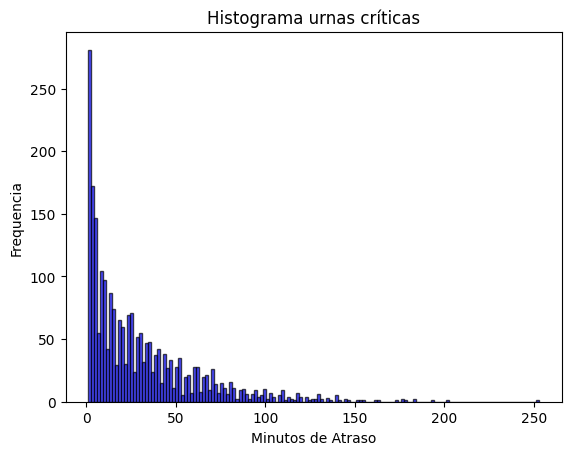

In [8]:
import matplotlib.pyplot as plt
da = df_atraso_1t.query("ATRASO_FILA_MINUTOS > 0")

plt.hist(df_atraso_1t['ATRASO_FILA_MINUTOS'], bins=150, color='blue', edgecolor='black', alpha=0.7)
plt.title('Histograma urnas críticas')
plt.xlabel('Minutos de Atraso')
plt.ylabel('Frequencia')
plt.show() 

In [9]:

media_1t = 55
corte_1t = 170

condicoes_1t = [
    (df_atraso_1t['ATRASO_FILA_MINUTOS'] < media_1t),
    (df_atraso_1t['ATRASO_FILA_MINUTOS'] >= media_1t) & (df_atraso_1t['ATRASO_FILA_MINUTOS'] < corte_1t),
    (df_atraso_1t['ATRASO_FILA_MINUTOS'] >= corte_1t)
]
rotulos_1t = ['1', '2', '3']

df_atraso_1t['STATUS'] = np.select(condicoes_1t, rotulos_1t, default='Indefinido')





print(df_atraso_1t['STATUS'].value_counts())
df_atraso_1t.to_csv('df_atraso_2018.csv', index=False, sep=';', encoding='utf-8-sig')



STATUS
1    1936
2     412
3       9
Name: count, dtype: int64


In [10]:
print("TODAS AS URNAS CRÍTICAS - 1º TURNO ")
# Filtra apenas as críticas e ordena do maior para o menor atraso, mostrando tudo
display(
    df_atraso_1t[df_atraso_1t['STATUS'] == '3']
    .sort_values(by='ATRASO_FILA_MINUTOS', ascending=False)
)

print("\n TODAS AS URNAS CRÍTICAS - 2º TURNO ")
# Filtra apenas as críticas e ordena do maior para o menor atraso, mostrando tudo


TODAS AS URNAS CRÍTICAS - 1º TURNO 


,NM_MUNICIPIO,NR_ZONA,NR_SECAO,TURNO,CONTINGENCIA,QT_ELEITORES_ANTES_17,DELTA_T_ANTES_17,DESVIO_ANTES_17,QT_ELEITORES_DEPOIS_17,DELTA_T_DEPOIS_17,DESVIO_DEPOIS_17,ULTIMO_VOTO,TIMEOUT_BIOMETRIA,TECLA_INDEVIDA,INATIVIDADE,SEM_BIOMETRIA,TITULO_INVALIDO,ATRASO_FILA_MINUTOS,STATUS
4305,Brejo Grande,0015,0196,1º Turno,Não,185,79.19,84.83,108,76.49,50.51,21:13:36,2,0,18,2,9,253,3
520,Pacatuba,0015,0233,1º Turno,Não,180,78.48,60.64,114,64.02,38.66,20:21:40,8,0,11,0,27,201,3
449,Riachão Do Dantas,0004,0133,1º Turno,Não,243,75.82,46.25,97,69.24,33.52,20:14:13,21,0,14,0,23,194,3
4350,Capela,0005,0071,1º Turno,Não,216,88.69,66.28,84,76.82,48.40,20:03:47,120,0,28,0,9,183,3
2148,Frei Paulo,0024,0110,1º Turno,Não,230,75.84,53.89,112,51.90,23.50,20:03:06,1,0,4,0,6,183,3
728,Pedrinhas,0004,0171,1º Turno,Não,231,62.42,41.84,94,64.30,44.47,19:59:10,72,0,7,1,17,179,3
430,Riachão Do Dantas,0004,0151,1º Turno,Não,229,82.40,62.72,83,81.71,59.27,19:57:37,17,0,26,0,30,177,3
748,Gararu,0008,0014,1º Turno,Não,197,83.31,45.95,88,69.85,38.43,19:57:26,54,0,12,0,16,177,3
4035,Lagarto,0012,0066,1º Turno,Não,209,85.95,85.17,90,66.50,46.89,19:54:45,75,0,25,1,3,174,3



 TODAS AS URNAS CRÍTICAS - 2º TURNO 


/tmp/ipykernel_55056/798562091.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  grafico = sns.barplot(


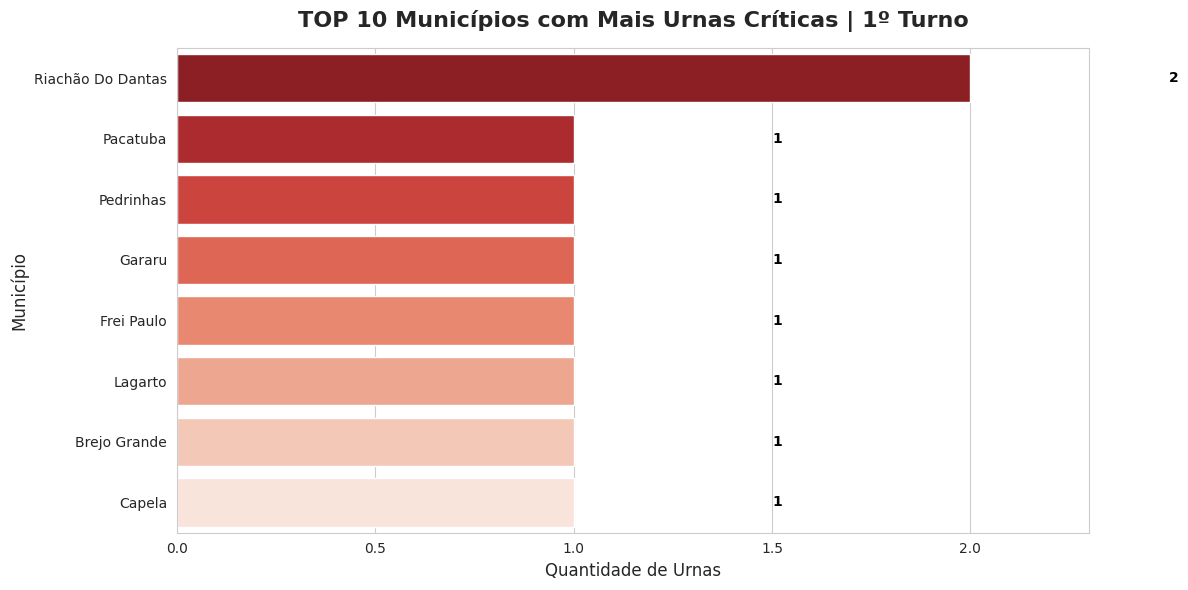

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Preparando os dados: Pegar apenas as urnas críticas do 1º turno
criticas_1t = df_atraso_1t[df_atraso_1t['STATUS'] == '3']

# 2. Contando quantas urnas críticas cada município teve e pegando o Top 10
top10_cidades = criticas_1t['NM_MUNICIPIO'].value_counts().head(10).reset_index()
top10_cidades.columns = ['Município', 'Qtd_Urnas_Criticas']

# 3. Configurando a beleza do gráfico
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid") # Fundo limpo

# 4. Desenhando o gráfico de barras horizontais
grafico = sns.barplot(
    x='Qtd_Urnas_Criticas', 
    y='Município', 
    data=top10_cidades, 
    palette='Reds_r' # Paleta de cores vermelhas (reforçando a ideia de alerta)
)

# 5. Adicionando os números na ponta de cada barra
for index, value in enumerate(top10_cidades['Qtd_Urnas_Criticas']):
    grafico.text(value + 0.5, index, str(value), color='black', va='center', fontweight='bold')

# 6. Títulos e eixos
plt.title('TOP 10 Municípios com Mais Urnas Críticas | 1º Turno', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Quantidade de Urnas', fontsize=12)
plt.ylabel('Município', fontsize=12)
plt.xlim(0, top10_cidades['Qtd_Urnas_Criticas'].max() * 1.15) # Dá um espaço extra para o texto caber

# Exibindo o gráfico final
plt.tight_layout()
plt.show()
criticas_1t.to_csv('secoes_criticas_2018.csv', index=False, sep=';', encoding='utf-8-sig')

STATUS
1    15.400826
2    24.752427
3    41.111111
Name: TIMEOUT_BIOMETRIA, dtype: float64


/tmp/ipykernel_55056/1062069445.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  grafico = sns.barplot(x=media_timeout_biometria.values,


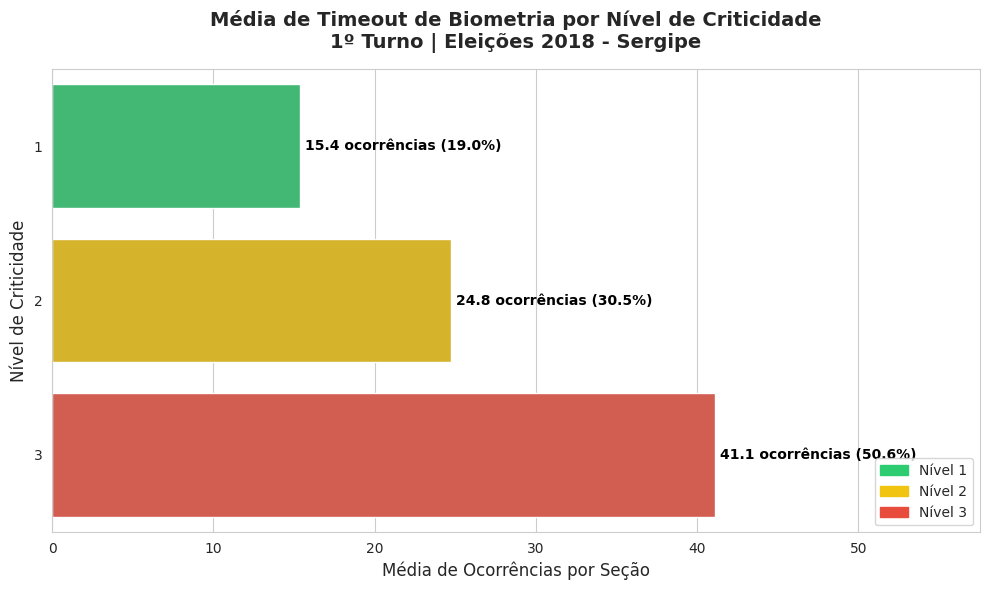

In [12]:
media_timeout_biometria = df_atraso_1t.groupby('STATUS')['TIMEOUT_BIOMETRIA'].mean()
print(media_timeout_biometria)

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

cores = ['#2ecc71', '#f1c40f', '#e74c3c']
grafico = sns.barplot(x=media_timeout_biometria.values, 
                      y=media_timeout_biometria.index.astype(str), 
                      palette=cores)

for index, value in enumerate(media_timeout_biometria.values):
    pct = (value / media_timeout_biometria.sum() * 100).round(1)
    grafico.text(value + 0.3, index, f'{value:.1f} ocorrências ({pct}%)', 
                 color='black', va='center', fontweight='bold', fontsize=10)

plt.title('Média de Timeout de Biometria por Nível de Criticidade\n1º Turno | Eleições 2018 - Sergipe', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Média de Ocorrências por Seção', fontsize=12)
plt.ylabel('Nível de Criticidade', fontsize=12)
plt.xlim(0, media_timeout_biometria.max() * 1.4)

labels = ['Nível 1', 'Nível 2', 'Nível 3']
handles = [plt.Rectangle((0,0),1,1, color=c) for c in cores]
plt.legend(handles, labels, loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

STATUS
1    11.580062
2    13.699029
3    15.555556
Name: TITULO_INVALIDO, dtype: float64


/tmp/ipykernel_55056/3797951348.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  grafico = sns.barplot(x=media_titulo_invalido.values,


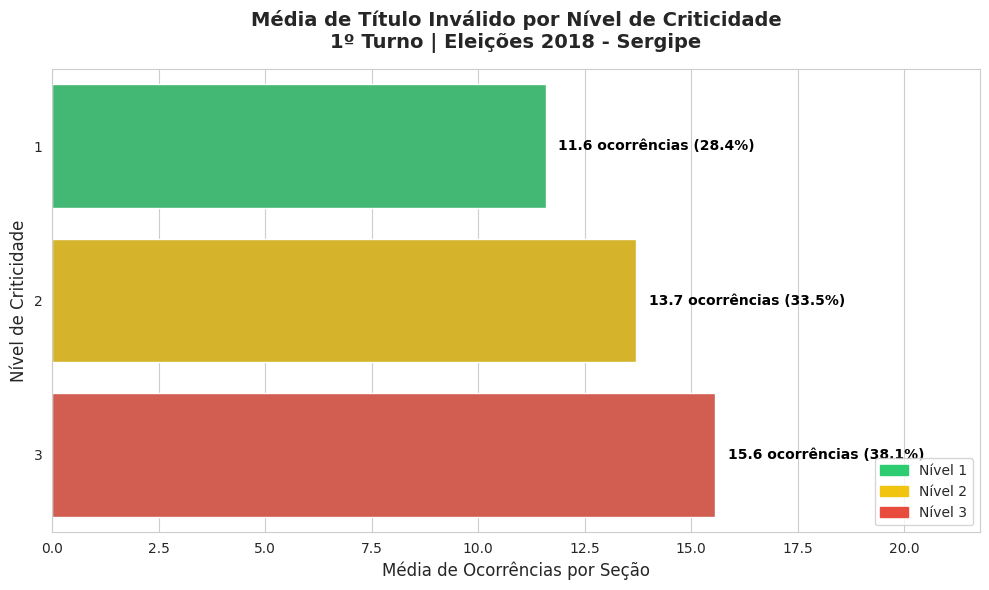

In [13]:
media_titulo_invalido = df_atraso_1t.groupby('STATUS')['TITULO_INVALIDO'].mean()
print(media_titulo_invalido)

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

cores = ['#2ecc71', '#f1c40f', '#e74c3c']
grafico = sns.barplot(x=media_titulo_invalido.values, 
                      y=media_titulo_invalido.index.astype(str), 
                      palette=cores)

for index, value in enumerate(media_titulo_invalido.values):
    pct = (value / media_titulo_invalido.sum() * 100).round(1)
    grafico.text(value + 0.3, index, f'{value:.1f} ocorrências ({pct}%)', 
                 color='black', va='center', fontweight='bold', fontsize=10)

plt.title('Média de Título Inválido por Nível de Criticidade\n1º Turno | Eleições 2018 - Sergipe', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Média de Ocorrências por Seção', fontsize=12)
plt.ylabel('Nível de Criticidade', fontsize=12)
plt.xlim(0, media_titulo_invalido.max() * 1.4)

labels = ['Nível 1', 'Nível 2', 'Nível 3']
handles = [plt.Rectangle((0,0),1,1, color=c) for c in cores]
plt.legend(handles, labels, loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

STATUS
1    10.539256
2    13.131068
3    16.111111
Name: INATIVIDADE, dtype: float64


/tmp/ipykernel_55056/2133458292.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  grafico = sns.barplot(x=media_inatividade.values,


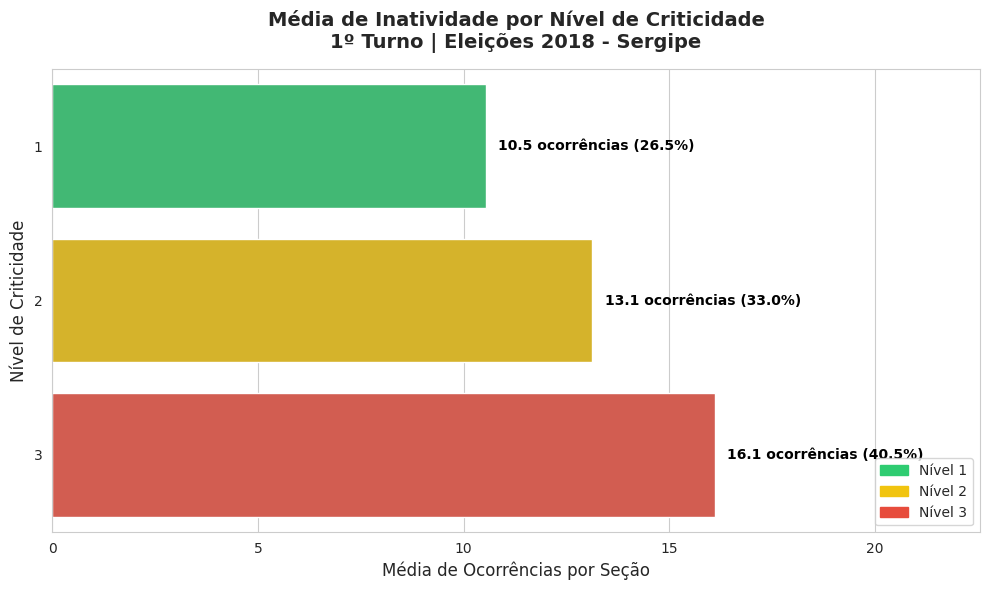

In [14]:
media_inatividade = df_atraso_1t.groupby('STATUS')['INATIVIDADE'].mean()
print(media_inatividade)

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

cores = ['#2ecc71', '#f1c40f', '#e74c3c']
grafico = sns.barplot(x=media_inatividade.values, 
                      y=media_inatividade.index.astype(str), 
                      palette=cores)

for index, value in enumerate(media_inatividade.values):
    pct = (value / media_inatividade.sum() * 100).round(1)
    grafico.text(value + 0.3, index, f'{value:.1f} ocorrências ({pct}%)', 
                 color='black', va='center', fontweight='bold', fontsize=10)

plt.title('Média de Inatividade por Nível de Criticidade\n1º Turno | Eleições 2018 - Sergipe', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Média de Ocorrências por Seção', fontsize=12)
plt.ylabel('Nível de Criticidade', fontsize=12)
plt.xlim(0, media_inatividade.max() * 1.4)

labels = ['Nível 1', 'Nível 2', 'Nível 3']
handles = [plt.Rectangle((0,0),1,1, color=c) for c in cores]
plt.legend(handles, labels, loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

STATUS
1    0.379649
2    0.449029
3    0.444444
Name: SEM_BIOMETRIA, dtype: float64


/tmp/ipykernel_55056/2793582717.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  grafico = sns.barplot(x=media_sem_biometria.values,


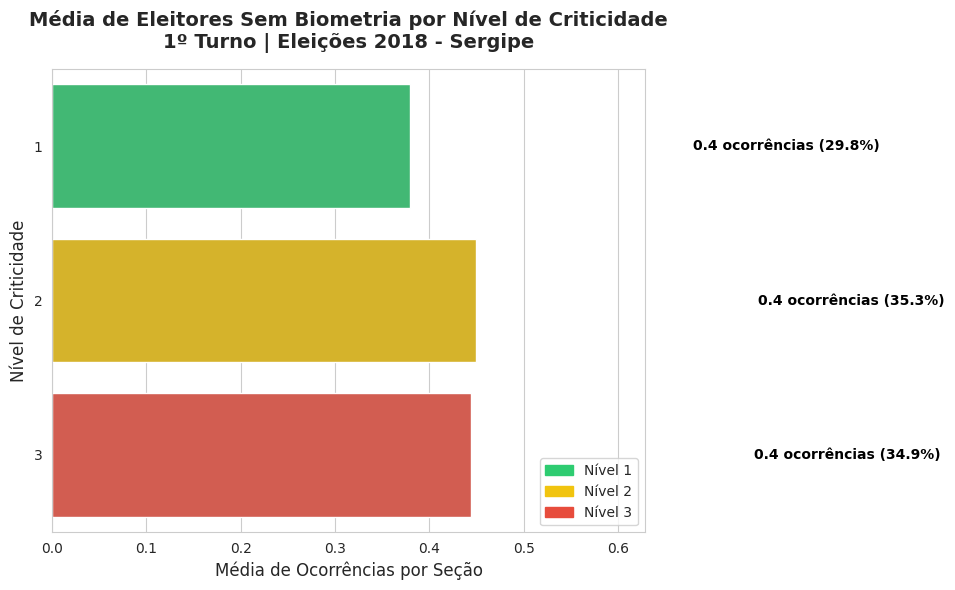

In [15]:
media_sem_biometria = df_atraso_1t.groupby('STATUS')['SEM_BIOMETRIA'].mean()
print(media_sem_biometria)

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

cores = ['#2ecc71', '#f1c40f', '#e74c3c']
grafico = sns.barplot(x=media_sem_biometria.values, 
                      y=media_sem_biometria.index.astype(str), 
                      palette=cores)

for index, value in enumerate(media_sem_biometria.values):
    pct = (value / media_sem_biometria.sum() * 100).round(1)
    grafico.text(value + 0.3, index, f'{value:.1f} ocorrências ({pct}%)', 
                 color='black', va='center', fontweight='bold', fontsize=10)

plt.title('Média de Eleitores Sem Biometria por Nível de Criticidade\n1º Turno | Eleições 2018 - Sergipe', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Média de Ocorrências por Seção', fontsize=12)
plt.ylabel('Nível de Criticidade', fontsize=12)
plt.xlim(0, media_sem_biometria.max() * 1.4)

labels = ['Nível 1', 'Nível 2', 'Nível 3']
handles = [plt.Rectangle((0,0),1,1, color=c) for c in cores]
plt.legend(handles, labels, loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

In [16]:
nivel3_2018 = pd.read_csv('secoes_criticas_2018.csv', sep=';', encoding='utf-8-sig')
nivel3_2022 = pd.read_csv('selcoes_criticas_2022.csv', sep=';', encoding='utf-8-sig')



In [17]:
df_perfil = pd.read_csv('perfil_eleitor_secao_2018_SE.csv', sep=';', encoding='latin1')

df_perfil['NM_MUNICIPIO'] = df_perfil['NM_MUNICIPIO'].str.upper()
nivel3_2018['NM_MUNICIPIO'] = nivel3_2018['NM_MUNICIPIO'].str.upper()
#df_perfil[df_perfil['NR_SECAO'] == 75].head(20)

In [18]:
df_perfil_n3 = nivel3_2018.merge(
    df_perfil,
    on=['NM_MUNICIPIO', 'NR_ZONA', 'NR_SECAO'],
    how='inner'
)

display(df_perfil_n3)

,NM_MUNICIPIO,NR_ZONA,NR_SECAO,TURNO,CONTINGENCIA,QT_ELEITORES_ANTES_17,DELTA_T_ANTES_17,DESVIO_ANTES_17,QT_ELEITORES_DEPOIS_17,DELTA_T_DEPOIS_17,...,DS_IDENTIDADE_GENERO,CD_QUILOMBOLA,DS_QUILOMBOLA,CD_INTERPRETE_LIBRAS,DS_INTERPRETE_LIBRAS,TP_OBRIGATORIEDADE_VOTO,QT_ELEITORES_PERFIL,QT_ELEITORES_BIOMETRIA,QT_ELEITORES_DEFICIENCIA,QT_ELEITORES_INC_NM_SOCIAL
0,RIACHÃO DO DANTAS,4,151,1º Turno,Não,229,82.40,62.72,83,81.71,...,#NE,-3,#NE,-3,#NE,Facultativo,2,2,0,0
1,RIACHÃO DO DANTAS,4,151,1º Turno,Não,229,82.40,62.72,83,81.71,...,#NE,-3,#NE,-3,#NE,Facultativo,1,1,0,0
2,RIACHÃO DO DANTAS,4,151,1º Turno,Não,229,82.40,62.72,83,81.71,...,#NE,-3,#NE,-3,#NE,Obrigatório,2,2,0,0
3,RIACHÃO DO DANTAS,4,151,1º Turno,Não,229,82.40,62.72,83,81.71,...,#NE,-3,#NE,-3,#NE,Obrigatório,5,5,0,0
4,RIACHÃO DO DANTAS,4,151,1º Turno,Não,229,82.40,62.72,83,81.71,...,#NE,-3,#NE,-3,#NE,Obrigatório,3,3,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1319,CAPELA,5,71,1º Turno,Não,216,88.69,66.28,84,76.82,...,#NE,-3,#NE,-3,#NE,Obrigatório,3,3,0,0
1320,CAPELA,5,71,1º Turno,Não,216,88.69,66.28,84,76.82,...,#NE,-3,#NE,-3,#NE,Facultativo,1,1,0,0
1321,CAPELA,5,71,1º Turno,Não,216,88.69,66.28,84,76.82,...,#NE,-3,#NE,-3,#NE,Facultativo,1,1,0,0
1322,CAPELA,5,71,1º Turno,Não,216,88.69,66.28,84,76.82,...,#NE,-3,#NE,-3,#NE,Facultativo,1,1,0,0


DS_FAIXA_ETARIA
16 anos                            18
17 anos                            12
18 anos                            54
19 anos                            87
20 anos                            83
21 a 24 anos                      362
25 a 29 anos                      403
30 a 34 anos                      357
35 a 39 anos                      366
40 a 44 anos                      355
45 a 49 anos                      275
50 a 54 anos                      241
55 a 59 anos                      225
60 a 64 anos                      172
65 a 69 anos                      135
70 a 74 anos                      112
75 a 79 anos                       71
80 a 84 anos                       32
85 a 89 anos                       12
90 a 94 anos                        3
95 a 99 anos                        3
Name: QT_ELEITORES_PERFIL, dtype: int64


/tmp/ipykernel_55056/4096209757.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  grafico = sns.barplot(x=df_idade.values, y=df_idade.index, palette='Blues_r')


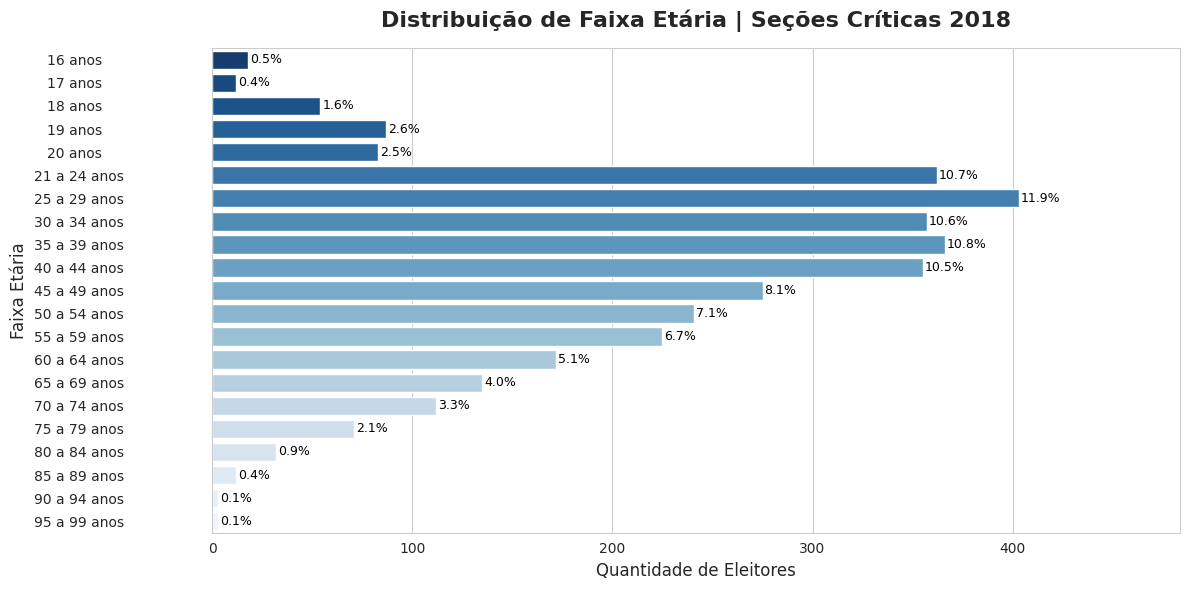

In [19]:
df_idade = df_perfil_n3.groupby('DS_FAIXA_ETARIA')['QT_ELEITORES_PERFIL'].sum()
print(df_idade)
plt.figure(figsize=(12, 6))
grafico = sns.barplot(x=df_idade.values, y=df_idade.index, palette='Blues_r')

# Adiciona o percentual na ponta de cada barra
total = df_idade.sum()
for index, value in enumerate(df_idade.values):
    pct = (value / total * 100).round(1)
    grafico.text(value + 1, index, f'{pct}%', color='black', va='center', fontsize=9)

plt.title('Distribuição de Faixa Etária | Seções Críticas 2018', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Quantidade de Eleitores', fontsize=12)
plt.ylabel('Faixa Etária', fontsize=12)
plt.xlim(0, df_idade.max() * 1.2)

plt.tight_layout()
plt.show()

DS_GRAU_ESCOLARIDADE
ANALFABETO                        475
ENSINO FUNDAMENTAL COMPLETO       107
ENSINO FUNDAMENTAL INCOMPLETO    1303
ENSINO MÉDIO COMPLETO             269
ENSINO MÉDIO INCOMPLETO           406
LÊ E ESCREVE                      742
SUPERIOR COMPLETO                  39
SUPERIOR INCOMPLETO                37
Name: QT_ELEITORES_PERFIL, dtype: int64


/tmp/ipykernel_55056/640981116.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  grafico = sns.barplot(x=df_escolaridade.values, y=df_escolaridade.index, palette='Blues_r')


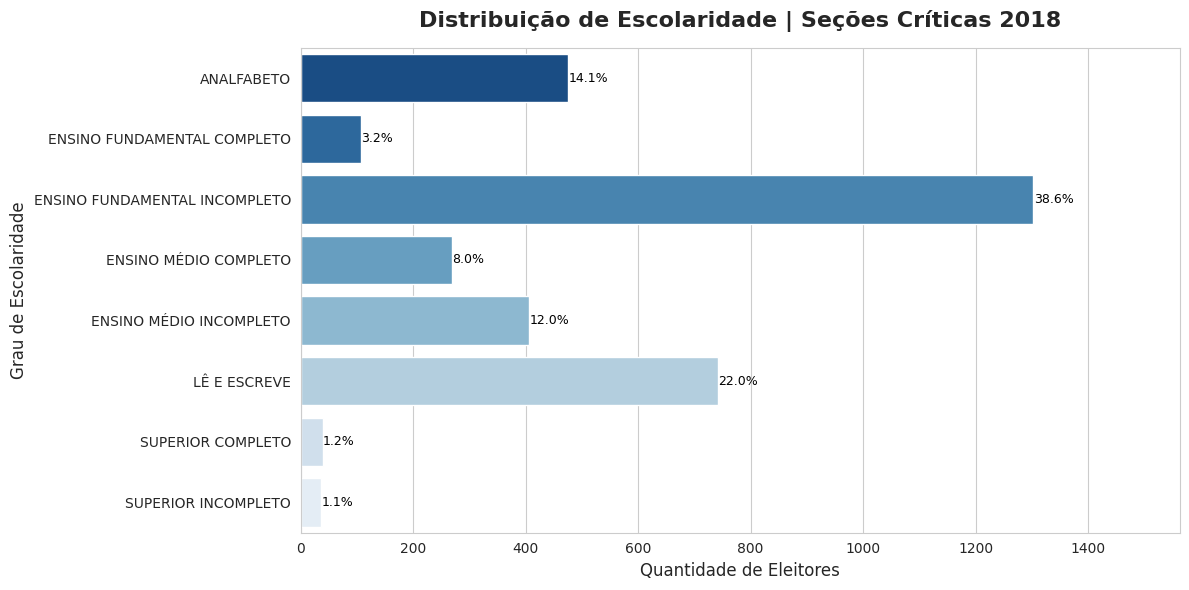

In [20]:
df_escolaridade = df_perfil_n3.groupby('DS_GRAU_ESCOLARIDADE')['QT_ELEITORES_PERFIL'].sum()
print(df_escolaridade)

plt.figure(figsize=(12, 6))
grafico = sns.barplot(x=df_escolaridade.values, y=df_escolaridade.index, palette='Blues_r')

# Adiciona o percentual na ponta de cada barra
total = df_escolaridade.sum()
for index, value in enumerate(df_escolaridade.values):
    pct = (value / total * 100).round(1)
    grafico.text(value + 1, index, f'{pct}%', color='black', va='center', fontsize=9)

plt.title('Distribuição de Escolaridade | Seções Críticas 2018', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Quantidade de Eleitores', fontsize=12)
plt.ylabel('Grau de Escolaridade', fontsize=12)
plt.xlim(0, df_escolaridade.max() * 1.2)

plt.tight_layout()
plt.show()

In [21]:
total_eleitores = df_perfil_n3['QT_ELEITORES_PERFIL'].sum()
pct_pcd = (10 / total_eleitores * 100).round(2)
print(f"Total de eleitores nas seções críticas: {total_eleitores}")
print(f"PCD representa: {pct_pcd}%")
total_biometria = df_perfil_n3['QT_ELEITORES_BIOMETRIA'].sum()
total_eleitores = df_perfil_n3['QT_ELEITORES_PERFIL'].sum()
pct_biometria = (total_biometria / total_eleitores * 100).round(2)
print(f"Total de eleitores com biometria: {total_biometria}")
print(f"Biometria representa: {pct_biometria}%")

Total de eleitores nas seções críticas: 3378
PCD representa: 0.3%
Total de eleitores com biometria: 3370
Biometria representa: 99.76%


In [26]:
nivel1 = df_atraso_1t[df_atraso_1t['STATUS'] == '1']
nivel2 = df_atraso_1t[df_atraso_1t['STATUS'] == '2']
df_perfil['NM_MUNICIPIO'] = df_perfil['NM_MUNICIPIO'].str.upper()
nivel2['NM_MUNICIPIO'] = nivel2['NM_MUNICIPIO'].str.upper()
nivel1['NM_MUNICIPIO'] = nivel1['NM_MUNICIPIO'].str.upper()
nivel1['NR_ZONA'] = nivel1['NR_ZONA'].astype(int)
nivel1['NR_SECAO'] = nivel1['NR_SECAO'].astype(int)
nivel2['NR_ZONA'] = nivel2['NR_ZONA'].astype(int)
nivel2['NR_SECAO'] = nivel2['NR_SECAO'].astype(int)

df_perfil_n2 = nivel2.merge(
    df_perfil,
    on=['NM_MUNICIPIO', 'NR_ZONA', 'NR_SECAO'],
    how='inner'
)

display(df_perfil_n2)

df_perfil_n1 = nivel1.merge(
    df_perfil,
    on=['NM_MUNICIPIO', 'NR_ZONA', 'NR_SECAO'],
    how='inner'
)

display(df_perfil_n1)

,NM_MUNICIPIO,NR_ZONA,NR_SECAO,TURNO,CONTINGENCIA,QT_ELEITORES_ANTES_17,DELTA_T_ANTES_17,DESVIO_ANTES_17,QT_ELEITORES_DEPOIS_17,DELTA_T_DEPOIS_17,...,DS_IDENTIDADE_GENERO,CD_QUILOMBOLA,DS_QUILOMBOLA,CD_INTERPRETE_LIBRAS,DS_INTERPRETE_LIBRAS,TP_OBRIGATORIEDADE_VOTO,QT_ELEITORES_PERFIL,QT_ELEITORES_BIOMETRIA,QT_ELEITORES_DEFICIENCIA,QT_ELEITORES_INC_NM_SOCIAL
0,TOMAR DO GERU,30,25,1º Turno,Não,203,100.92,113.07,35,76.11,...,#NE,-3,#NE,-3,#NE,Obrigatório,5,5,0,0
1,TOMAR DO GERU,30,25,1º Turno,Não,203,100.92,113.07,35,76.11,...,#NE,-3,#NE,-3,#NE,Obrigatório,2,2,0,0
2,TOMAR DO GERU,30,25,1º Turno,Não,203,100.92,113.07,35,76.11,...,#NE,-3,#NE,-3,#NE,Obrigatório,4,4,0,0
3,TOMAR DO GERU,30,25,1º Turno,Não,203,100.92,113.07,35,76.11,...,#NE,-3,#NE,-3,#NE,Facultativo,1,1,0,0
4,TOMAR DO GERU,30,25,1º Turno,Não,203,100.92,113.07,35,76.11,...,#NE,-3,#NE,-3,#NE,Obrigatório,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63043,BOQUIM,4,179,1º Turno,Não,228,83.76,70.30,53,59.02,...,#NE,-3,#NE,-3,#NE,Obrigatório,1,1,0,0
63044,BOQUIM,4,179,1º Turno,Não,228,83.76,70.30,53,59.02,...,#NE,-3,#NE,-3,#NE,Obrigatório,4,4,0,0
63045,BOQUIM,4,179,1º Turno,Não,228,83.76,70.30,53,59.02,...,#NE,-3,#NE,-3,#NE,Facultativo,1,1,0,0
63046,BOQUIM,4,179,1º Turno,Não,228,83.76,70.30,53,59.02,...,#NE,-3,#NE,-3,#NE,Obrigatório,3,3,0,0


,NM_MUNICIPIO,NR_ZONA,NR_SECAO,TURNO,CONTINGENCIA,QT_ELEITORES_ANTES_17,DELTA_T_ANTES_17,DESVIO_ANTES_17,QT_ELEITORES_DEPOIS_17,DELTA_T_DEPOIS_17,...,DS_IDENTIDADE_GENERO,CD_QUILOMBOLA,DS_QUILOMBOLA,CD_INTERPRETE_LIBRAS,DS_INTERPRETE_LIBRAS,TP_OBRIGATORIEDADE_VOTO,QT_ELEITORES_PERFIL,QT_ELEITORES_BIOMETRIA,QT_ELEITORES_DEFICIENCIA,QT_ELEITORES_INC_NM_SOCIAL
0,TOMAR DO GERU,30,36,1º Turno,Não,243,77.65,47.63,3,99.00,...,#NE,-3,#NE,-3,#NE,Obrigatório,5,5,0,0
1,TOMAR DO GERU,30,36,1º Turno,Não,243,77.65,47.63,3,99.00,...,#NE,-3,#NE,-3,#NE,Obrigatório,4,4,0,0
2,TOMAR DO GERU,30,36,1º Turno,Não,243,77.65,47.63,3,99.00,...,#NE,-3,#NE,-3,#NE,Obrigatório,1,1,0,0
3,TOMAR DO GERU,30,36,1º Turno,Não,243,77.65,47.63,3,99.00,...,#NE,-3,#NE,-3,#NE,Obrigatório,1,1,0,0
4,TOMAR DO GERU,30,36,1º Turno,Não,243,77.65,47.63,3,99.00,...,#NE,-3,#NE,-3,#NE,Facultativo,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
291191,BOQUIM,4,189,1º Turno,Não,268,63.17,69.95,18,48.72,...,#NE,-3,#NE,-3,#NE,Obrigatório,1,1,0,0
291192,BOQUIM,4,189,1º Turno,Não,268,63.17,69.95,18,48.72,...,#NE,-3,#NE,-3,#NE,Obrigatório,1,1,0,0
291193,BOQUIM,4,189,1º Turno,Não,268,63.17,69.95,18,48.72,...,#NE,-3,#NE,-3,#NE,Obrigatório,1,1,0,0
291194,BOQUIM,4,189,1º Turno,Não,268,63.17,69.95,18,48.72,...,#NE,-3,#NE,-3,#NE,Obrigatório,5,5,0,0


DS_FAIXA_ETARIA
100 anos ou mais                     69
16 anos                            1891
17 anos                            4263
18 anos                            9814
19 anos                           12383
20 anos                           13827
21 a 24 anos                      65744
25 a 29 anos                      78746
30 a 34 anos                      79698
35 a 39 anos                      77264
40 a 44 anos                      67595
45 a 49 anos                      57866
50 a 54 anos                      51504
55 a 59 anos                      41508
60 a 64 anos                      31341
65 a 69 anos                      23626
70 a 74 anos                      17003
75 a 79 anos                      10552
80 a 84 anos                       4959
85 a 89 anos                       2070
90 a 94 anos                        727
95 a 99 anos                        148
Inválido                              9
Name: QT_ELEITORES_PERFIL, dtype: int64
DS_FAIXA_ETARIA
100 anos

/tmp/ipykernel_55056/2104972052.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_idade_n1.values, y=df_idade_n1.index, palette='Greens_r', ax=ax1)
/tmp/ipykernel_55056/2104972052.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_idade_n2.values, y=df_idade_n2.index, palette='Oranges_r', ax=ax2)


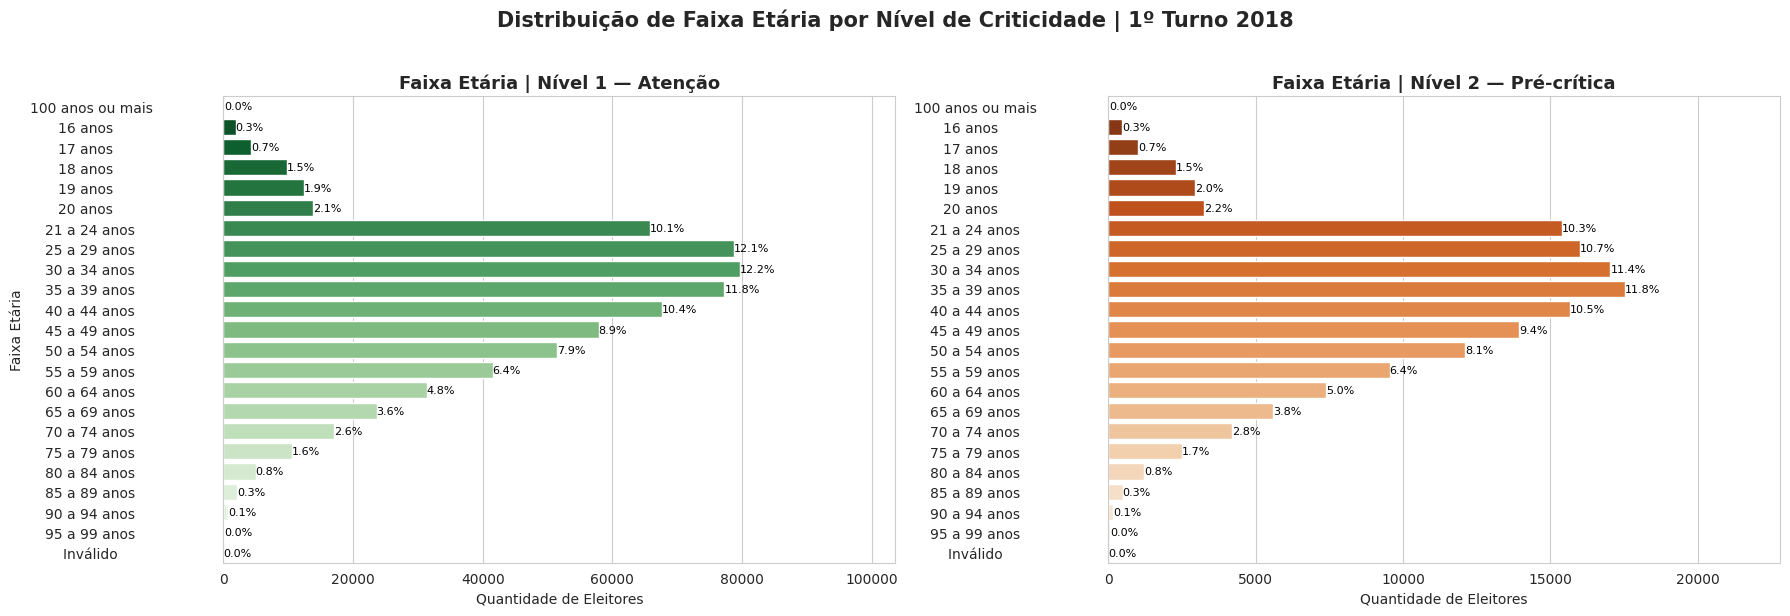

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Nível 1
df_idade_n1 = df_perfil_n1.groupby('DS_FAIXA_ETARIA')['QT_ELEITORES_PERFIL'].sum()
print(df_idade_n1)
sns.barplot(x=df_idade_n1.values, y=df_idade_n1.index, palette='Greens_r', ax=ax1)
total_n1 = df_idade_n1.sum()
for index, value in enumerate(df_idade_n1.values):
    pct = (value / total_n1 * 100).round(1)
    ax1.text(value + 0.5, index, f'{pct}%', color='black', va='center', fontsize=8)
ax1.set_title('Faixa Etária | Nível 1 — Atenção', fontsize=13, fontweight='bold')
ax1.set_xlabel('Quantidade de Eleitores')
ax1.set_ylabel('Faixa Etária')
ax1.set_xlim(0, df_idade_n1.max() * 1.3)

# Nível 2
df_idade_n2 = df_perfil_n2.groupby('DS_FAIXA_ETARIA')['QT_ELEITORES_PERFIL'].sum()
print(df_idade_n2)
sns.barplot(x=df_idade_n2.values, y=df_idade_n2.index, palette='Oranges_r', ax=ax2)
total_n2 = df_idade_n2.sum()
for index, value in enumerate(df_idade_n2.values):
    pct = (value / total_n2 * 100).round(1)
    ax2.text(value + 0.5, index, f'{pct}%', color='black', va='center', fontsize=8)
ax2.set_title('Faixa Etária | Nível 2 — Pré-crítica', fontsize=13, fontweight='bold')
ax2.set_xlabel('Quantidade de Eleitores')
ax2.set_ylabel('')
ax2.set_xlim(0, df_idade_n2.max() * 1.3)

plt.suptitle('Distribuição de Faixa Etária por Nível de Criticidade | 1º Turno 2018', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

DS_GRAU_ESCOLARIDADE
ANALFABETO                        36022
ENSINO FUNDAMENTAL COMPLETO       29401
ENSINO FUNDAMENTAL INCOMPLETO    205602
ENSINO MÉDIO COMPLETO            137573
ENSINO MÉDIO INCOMPLETO           98779
LÊ E ESCREVE                      71775
SUPERIOR COMPLETO                 40550
SUPERIOR INCOMPLETO               32905
Name: QT_ELEITORES_PERFIL, dtype: int64
DS_GRAU_ESCOLARIDADE
ANALFABETO                       11855
ENSINO FUNDAMENTAL COMPLETO       6270
ENSINO FUNDAMENTAL INCOMPLETO    53636
ENSINO MÉDIO COMPLETO            23954
ENSINO MÉDIO INCOMPLETO          21356
LÊ E ESCREVE                     23330
SUPERIOR COMPLETO                 4510
SUPERIOR INCOMPLETO               3996
Name: QT_ELEITORES_PERFIL, dtype: int64


/tmp/ipykernel_55056/546773476.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_esc_n1.values, y=df_esc_n1.index, palette='Greens_r', ax=ax1)
/tmp/ipykernel_55056/546773476.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_esc_n2.values, y=df_esc_n2.index, palette='Oranges_r', ax=ax2)


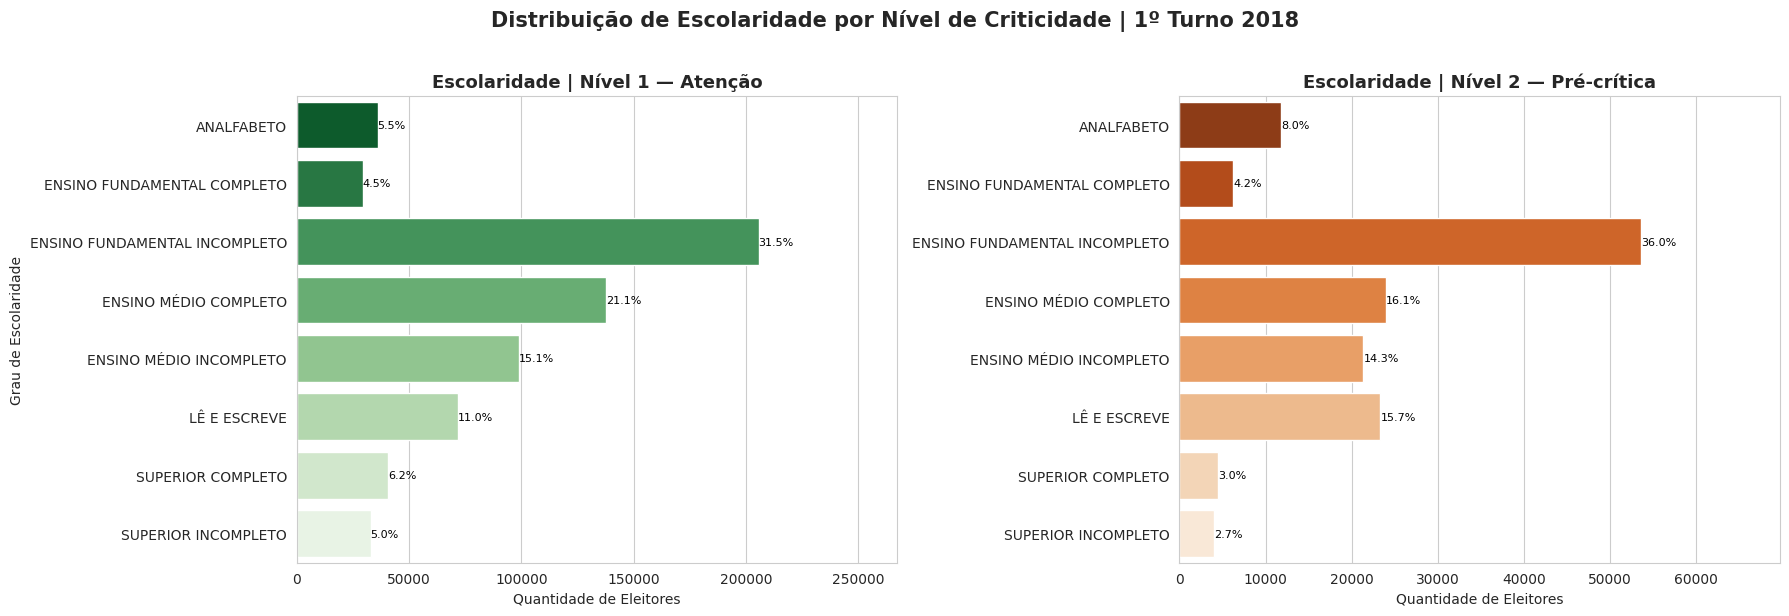

In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Nível 1
df_esc_n1 = df_perfil_n1.groupby('DS_GRAU_ESCOLARIDADE')['QT_ELEITORES_PERFIL'].sum()
print(df_esc_n1)
sns.barplot(x=df_esc_n1.values, y=df_esc_n1.index, palette='Greens_r', ax=ax1)
total_n1 = df_esc_n1.sum()
for index, value in enumerate(df_esc_n1.values):
    pct = (value / total_n1 * 100).round(1)
    ax1.text(value + 0.5, index, f'{pct}%', color='black', va='center', fontsize=8)
ax1.set_title('Escolaridade | Nível 1 — Atenção', fontsize=13, fontweight='bold')
ax1.set_xlabel('Quantidade de Eleitores')
ax1.set_ylabel('Grau de Escolaridade')
ax1.set_xlim(0, df_esc_n1.max() * 1.3)

# Nível 2
df_esc_n2 = df_perfil_n2.groupby('DS_GRAU_ESCOLARIDADE')['QT_ELEITORES_PERFIL'].sum()
print(df_esc_n2)
sns.barplot(x=df_esc_n2.values, y=df_esc_n2.index, palette='Oranges_r', ax=ax2)
total_n2 = df_esc_n2.sum()
for index, value in enumerate(df_esc_n2.values):
    pct = (value / total_n2 * 100).round(1)
    ax2.text(value + 0.5, index, f'{pct}%', color='black', va='center', fontsize=8)
ax2.set_title('Escolaridade | Nível 2 — Pré-crítica', fontsize=13, fontweight='bold')
ax2.set_xlabel('Quantidade de Eleitores')
ax2.set_ylabel('')
ax2.set_xlim(0, df_esc_n2.max() * 1.3)

plt.suptitle('Distribuição de Escolaridade por Nível de Criticidade | 1º Turno 2018', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [29]:
# PCD
total_pcd_n1 = df_perfil_n1['QT_ELEITORES_DEFICIENCIA'].sum()
total_pcd_n2 = df_perfil_n2['QT_ELEITORES_DEFICIENCIA'].sum()
total_el_n1 = df_perfil_n1['QT_ELEITORES_PERFIL'].sum()
total_el_n2 = df_perfil_n2['QT_ELEITORES_PERFIL'].sum()


print(f"Nível 1 — Total PCD: {total_pcd_n1}")
print(f"           Representa: {(total_pcd_n1/total_el_n1*100):.2f}%")
print(f"Nível 2 — Total PCD: {total_pcd_n2}")
print(f"           Representa: {(total_pcd_n2/total_el_n2*100):.2f}%")

# Biometria
total_bio_n1 = df_perfil_n1['QT_ELEITORES_BIOMETRIA'].sum()
total_bio_n2 = df_perfil_n2['QT_ELEITORES_BIOMETRIA'].sum()

print(f"Nível 1 — Total com biometria: {total_bio_n1}")
print(f"           Representa: {(total_bio_n1/total_el_n1*100):.2f}%")
print(f"Nível 2 — Total com biometria: {total_bio_n2}")
print(f"           Representa: {(total_bio_n2/total_el_n2*100):.2f}%")

Nível 1 — Total PCD: 2226
           Representa: 0.34%
Nível 2 — Total PCD: 469
           Representa: 0.31%
Nível 1 — Total com biometria: 651490
           Representa: 99.83%
Nível 2 — Total com biometria: 148645
           Representa: 99.82%
